# Experiment: Detectron2 Keypoints Demo

What this notebook teaches:
- Install Detectron2 in Colab and load a keypoint R-CNN model.
- Run person keypoint inference and visualize predictions.
- Map Detectron2 keypoints to the shared canonical schema.
- Export keypoints and write a mini benchmark artifact.


In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sumeyye-agac/human-pose-estimation-experiments.git"
REPO_NAME = "human-pose-estimation-experiments"
COLAB_REPO_DIR = Path("/content") / REPO_NAME

if "google.colab" in sys.modules:
    if not COLAB_REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(COLAB_REPO_DIR)], check=True)
    os.chdir(COLAB_REPO_DIR)

repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError("Could not locate repository root containing src/.")

os.chdir(repo_root)
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

print(f"Using repo root: {repo_root}")


Using repo root: /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments


In [2]:
def pip_install(*packages: str) -> None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade-strategy", "only-if-needed", *packages], check=True)

pip_install(
    "numpy<2",
    "pandas>=2.1,<2.3",
    "matplotlib>=3.8,<3.9",
    "opencv-python-headless<5",
)

# Detectron2 setup with idempotent guard.
try:
    import detectron2
    print("Detectron2 already available:", getattr(detectron2, "__version__", "unknown"))
except Exception:
    print("Detectron2 not found. Trying best-effort install path...")
    try:
        pip_install("torch", "torchvision")
        pip_install("git+https://github.com/facebookresearch/detectron2.git")
    except Exception as exc:
        print(f"Detectron2 install warning: {exc}")


Detectron2 already available: 0.6


If Detectron2 import fails, skip inference in this notebook and use the fallback path in `docs/limitations.md`.


/Users/sumeyyeagac/anaconda3/envs/posebench-d2/lib/python3.10/site-packages/detectron2/model_zoo/model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


An exception occurred in telemetry logging.Disabling telemetry to prevent further exceptions.
Traceback (most recent call last):
  File "/Users/sumeyyeagac/anaconda3/envs/posebench-d2/lib/python3.10/site-packages/iopath/common/file_io.py", line 946, in __log_tmetry_keys
    handler.log_event()
  File "/Users/sumeyyeagac/anaconda3/envs/posebench-d2/lib/python3.10/site-packages/iopath/common/event_logger.py", line 97, in log_event
    del self._evt
AttributeError: _evt


An exception occurred in telemetry logging.Disabling telemetry to prevent further exceptions.
Traceback (most recent call last):
  File "/Users/sumeyyeagac/anaconda3/envs/posebench-d2/lib/python3.10/site-packages/iopath/common/file_io.py", line 946, in __log_tmetry_keys
    handler.log_event()
  File "/Users/sumeyyeagac/anaconda3/envs/posebench-d2/lib/python3.10/site-packages/iopath/common/event_logger.py", line 97, in log_event
    del self._evt
AttributeError: _evt


/Users/sumeyyeagac/anaconda3/envs/posebench-d2/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1770196967836/work/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


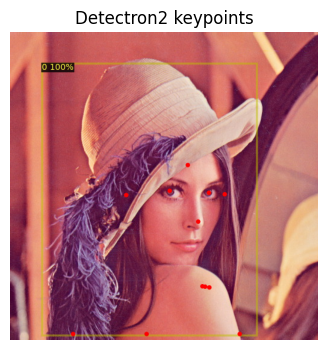

{'tool': 'detectron2',
 'status': 'measured',
 'avg_ms_per_frame': 895.6694545922801,
 'std_ms_per_frame': 3.292824938111223,
 'fps': 1.1164833129820335,
 'measured_frames': 12,
 'warmup_frames': 4,
 'repeat': 1,
 'include_decode': False}

In [3]:
import json
import urllib.request
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
from posebench.benchmark import BenchmarkConfig, benchmark_backend, write_json
from posebench.export import export_frames_to_csv, export_frames_to_json
from posebench.keypoints_schema import map_tool_keypoints_to_canonical
status_payload = {"tool": "detectron2", "status": "not_measured", "notes": "Detectron2 unavailable"}
try:
    from detectron2 import model_zoo
    from detectron2.config import get_cfg
    from detectron2.engine import DefaultPredictor
    from detectron2.utils.visualizer import Visualizer
    detectron2_ready = True
except Exception as exc:
    detectron2_ready = False
    status_payload["notes"] = f"Detectron2 import failed: {exc}"
sample_path = repo_root / "assets" / "sample_input_walking.jpg"
def download_file(url: str, destination: Path) -> None:
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(request, timeout=20) as response, destination.open("wb") as f:
        f.write(response.read())
def ensure_sample_image(path: Path) -> Path:
    if path.exists():
        return path
    candidates = [
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg",
        "https://images.pexels.com/photos/936075/pexels-photo-936075.jpeg?auto=compress&cs=tinysrgb&w=640",
    ]
    last_error = None
    for url in candidates:
        try:
            download_file(url, path)
            return path
        except Exception as exc:
            last_error = exc
    canvas = np.full((480, 640, 3), 245, dtype=np.uint8)
    cv2.circle(canvas, (320, 100), 36, (40, 40, 40), 3)
    cv2.line(canvas, (320, 136), (320, 320), (40, 40, 40), 3)
    cv2.line(canvas, (320, 200), (250, 260), (40, 40, 40), 3)
    cv2.line(canvas, (320, 200), (390, 260), (40, 40, 40), 3)
    cv2.line(canvas, (320, 320), (270, 430), (40, 40, 40), 3)
    cv2.line(canvas, (320, 320), (370, 430), (40, 40, 40), 3)
    cv2.putText(canvas, "Synthetic fallback image", (170, 460), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (20, 20, 20), 2)
    cv2.imwrite(str(path), canvas)
    print(f"Sample image download failed ({last_error}); synthetic fallback generated.")
    return path
ensure_sample_image(sample_path)
bgr = cv2.imread(str(sample_path))
if bgr is None:
    raise RuntimeError("Could not load sample image")
if detectron2_ready:
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file("COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x.yaml"))
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7
    cfg.MODEL.DEVICE = "cpu"
    cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Keypoints/keypoint_rcnn_R_50_FPN_3x.yaml")
    try:
        predictor = DefaultPredictor(cfg)
        outputs = predictor(bgr)
        instances = outputs["instances"].to("cpu")
        keypoints = instances.pred_keypoints.numpy() if instances.has("pred_keypoints") else None
        if keypoints is None or len(keypoints) == 0:
            raise RuntimeError("No keypoints detected by Detectron2")
        first_person = keypoints[0]
        points = [
            {"x": float(kp[0]), "y": float(kp[1]), "confidence": float(kp[2])}
            for kp in first_person
        ]
        canonical = map_tool_keypoints_to_canonical("detectron2", points, min_confidence=0.1)
        frames = [
            {
                "frame_index": 0,
                "timestamp_ms": 0.0,
                "person_id": 0,
                "tool": "detectron2",
                "schema": "coco17",
                "keypoints": canonical,
            }
        ]
        export_frames_to_csv(frames, repo_root / "results" / "detectron2_demo_keypoints.csv")
        export_frames_to_json(frames, repo_root / "results" / "detectron2_demo_keypoints.json")
        vis = Visualizer(bgr[:, :, ::-1], metadata=None, scale=1.0)
        vis_img = vis.draw_instance_predictions(instances).get_image()
        out_path = repo_root / "assets" / "generated" / "detectron2_demo_overlay.jpg"
        out_path.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(out_path), vis_img[:, :, ::-1])
        plt.figure(figsize=(7, 4))
        plt.imshow(vis_img)
        plt.axis("off")
        plt.title("Detectron2 keypoints")
        plt.show()
        class D2Backend:
            name = "detectron2"
            def __init__(self, predictor_obj):
                self.predictor_obj = predictor_obj
            def infer(self, frame: np.ndarray):
                return self.predictor_obj(frame)
        bench_result = benchmark_backend(
            backend=D2Backend(predictor),
            frames=[bgr],
            config=BenchmarkConfig(warmup_frames=4, measured_frames=12, repeat=1),
        )
        write_json(bench_result, repo_root / "results" / "benchmark_raw_detectron2_demo.json")
        status_payload = bench_result
    except Exception as exc:
        status_payload = {
            "tool": "detectron2",
            "status": "not_measured",
            "notes": f"Detectron2 runtime failed: {exc}",
        }
        write_json(status_payload, repo_root / "results" / "benchmark_raw_detectron2_demo.json")
else:
    write_json(status_payload, repo_root / "results" / "benchmark_raw_detectron2_demo.json")
status_payload
